In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbdata
import datetime
import plotly.express as px

In [2]:
# fetch data of world bank total population and gdp per capita for the year 2023

# Define the indicator for population (SP.POP.TOTL)
indicator = {
    'SP.POP.TOTL': 'total_population'
             }

# Define countries (India and Pakistan)
# countries = ['IN', 'PK', 'BD', 'LK', 'AF']  # 'IN' for India, 'PK' for Pakistan

# Fetch data
data = wbdata.get_dataframe(indicator, 
                            # country=countries,
                            )

# Reset index to convert it into a DataFrame
data.reset_index(inplace=True)

# Rename columns for clarity
data.rename(columns={'country': 'Country', 'date': 'Year'}, inplace=True)

# Ensure Year column is numeric
data['Year'] = pd.to_numeric(data['Year'])

# Filter data between 1960 and 2023
df = data[(data['Year'] <= 2025) & (data['Year'] >= 1980)]
df.sample(5, random_state=42)

# # Save to a CSV file (optional)
data.to_csv("total_population.csv", index=False)

# # Display the first few rows of data
print(data.head())


                       Country  Year  total_population
0  Africa Eastern and Southern  2025               NaN
1  Africa Eastern and Southern  2024       769280888.0
2  Africa Eastern and Southern  2023       750491370.0
3  Africa Eastern and Southern  2022       731821393.0
4  Africa Eastern and Southern  2021       713090928.0


In [3]:
df.info()

<class 'wbdata.client.DataFrame'>
Index: 12236 entries, 0 to 17535
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           12236 non-null  object 
 1   Year              12236 non-null  int64  
 2   total_population  11915 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 382.4+ KB


/tmp/ipykernel_18582/2116942670.py:2: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(df[df['Year'] == 2025],


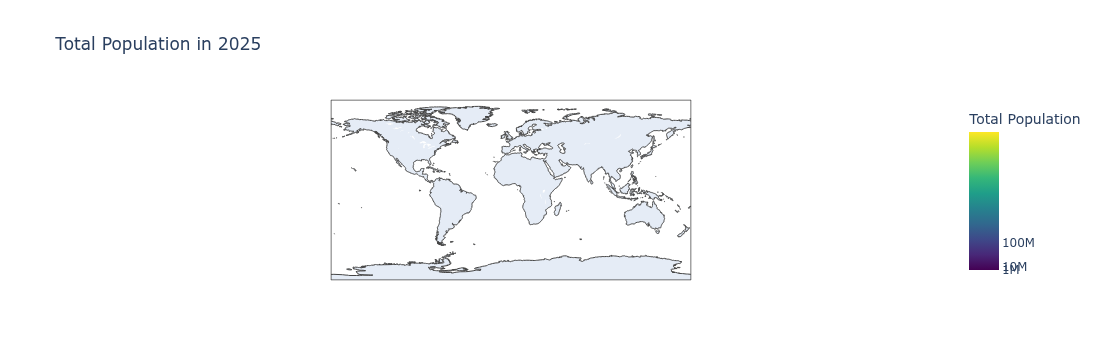

In [4]:
# make choropleth map of total population using plotly
fig = px.choropleth(df[df['Year'] == 2025], 
                    locations="Country",
                    locationmode='country names',
                    color="total_population",
                    hover_name="Country",
                    color_continuous_scale=px.colors.sequential.Viridis, # 'Viridis',
                    title="Total Population in 2025",
                    labels={'total_population': 'Total Population'}
                    )
# limit the scale of the colorbar
fig.update_layout(
    coloraxis_colorbar=dict(
        title='Total Population',
        tickvals=[1e6, 1e7, 1e8, 1.5e9],  # Custom tick values
        ticktext=['1M', '10M', '100M', '1.5B']  # Custom tick labels
    ),
    coloraxis=dict(
        cmin=0,  # Minimum value
        cmax=0.5e9  # Maximum value set to 1.5 billion
    )
)
fig.show()